# Acinar protein co-localisation

In [2]:
import os
import sys
import pathlib
import contextlib
import warnings
from typing import List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from tifffile import imread
from scipy.ndimage import uniform_filter
from skimage.transform import resize
from joblib import Parallel, delayed
import joblib
from tqdm import tqdm

# Pull the production-grade acinus segmentation from WIP_Acinar_Code
ACINAR_DIR = pathlib.Path("WIP_Acinar_Code").resolve()
if str(ACINAR_DIR) not in sys.path:
    sys.path.insert(0, str(ACINAR_DIR))
from acinar_analysis import segment_acinus, read_pixel_size  # noqa: E402

warnings.filterwarnings("ignore")


## Configuration

All paths and per-experiment channel assignments live here.

`EXPERIMENTS` maps an experiment label → `(image_folder, output_csv, channel_names)`. The keyword used to detect the experiment in the filename is taken from the dict key after lower-casing & stripping underscores.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
ROOT_DIR    = pathlib.Path(r"E:\PROTEIN_COLOCALISATION_IMAGES")
OUTPUT_DIR  = pathlib.Path(".")
DAPI_CHANNEL     = 0
MEMBRANE_CHANNEL = 2
NUM_CHANNELS     = 4
NUM_WORKERS      = 3 # lower if you're on your laptop!

# Per-experiment configuration: subfolder + channel name list.
# Channel order MUST match the channel index in the TIF.
EXPERIMENTS = {"Yap_Vinc": {"channels": ["DAPI", "YAP", "CAAX", "Vinculin"]},}
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# ── Helpers ──────────────────────────────────────────────────────────────────
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Patch joblib so each completed task ticks a tqdm progress bar."""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_cb = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_cb
        tqdm_object.close()


def to_uint8(img: np.ndarray) -> np.ndarray:
    """Linearly rescale an array to the full uint8 range (handles flat images)."""
    img = np.asarray(img)
    imin, imax = float(img.min()), float(img.max())
    if imax == imin:
        return np.zeros_like(img, dtype=np.uint8)
    return ((img - imin) * (255.0 / (imax - imin))).astype(np.uint8)


def channel_names_for(filename: str) -> Optional[List[str]]:
    """Look up the channel-name list for an image based on its filename keyword.
    Returns None if no experiment configuration matches.
    """
    fn = filename.replace("_", "").lower()
    for exp_label, cfg in EXPERIMENTS.items():
        if exp_label.replace("_", "").lower() in fn:
            return cfg["channels"]
    return None


In [ ]:
def add_image_details(df: pd.DataFrame, filename: str, flag: str) -> pd.DataFrame:
    """Add experimental metadata extracted from the (lower-cased) filename."""
    df = df.copy()
    df["filename"] = filename
    df["flag"] = flag

    df["well"] = 1 if "well1" in filename else 2

    if   "d0" in filename: df["day"] = 0
    elif "d1" in filename: df["day"] = 1
    elif "d3" in filename: df["day"] = 3
    else:                  df["day"] = 7

    if   "soft"  in filename: df["condition"] = "soft"
    elif "stiff" in filename: df["condition"] = "stiff"
    else:                     df["condition"] = "blank"

    df["image_type"] = df["condition"].astype(str) + ", d" + df["day"].astype(str)
    return df


In [ ]:
def load_image_and_extract_correlation(
    path: pathlib.Path,
    no_channels: int = NUM_CHANNELS,
    DAPI_channel: int = DAPI_CHANNEL,
    membrane_channel: int = MEMBRANE_CHANNEL,
    to_plot: bool = False,
    smoothing_sigma: float = 3.0,
) -> pd.DataFrame:
    """Segment the largest acinus in a TIF stack and compute channel correlations.

    Parameters
    ----------
    path
        Path to a multi-channel 3-D TIF stack of shape (Z, C, Y, X).
    no_channels
        Number of channels in the stack.
    DAPI_channel, membrane_channel
        Indices used to approximate the acinus (DAPI + membrane).
    to_plot
        If True, display a QC figure of the mid-slice segmentation.
    smoothing_sigma
        Forwarded to `segment_acinus`.

    Returns
    -------
    pd.DataFrame
        Pearson correlation matrix between channels with appended metadata.
        Returns an empty (channel-named) frame with `flag="FAILED"` on error.
    """
    path = pathlib.Path(path)
    filename = path.name.replace("_", "").lower()

    channel_names = channel_names_for(filename)
    if channel_names is None:
        warnings.warn(f"No channel mapping for {path.name} — skipping")
        return add_image_details(pd.DataFrame(columns=[f"ch{i}" for i in range(no_channels)]), filename, flag="NO_CHANNEL_MAP")

    try:
        # ── Load + normalise to uint8 (preserves the original behaviour) ──
        multi_channel_image = to_uint8(imread(str(path)))
        if multi_channel_image.ndim != 4:
            raise ValueError(f"Expected (Z,C,Y,X), got {multi_channel_image.shape}")

        # ── Acinus segmentation via WIP_Acinar_Code.segment_acinus ────────
        acinus_image = (
            multi_channel_image[:, DAPI_channel].astype(np.float32) +
            multi_channel_image[:, membrane_channel].astype(np.float32)
        )
        spacing = read_pixel_size(path)
        acinus_mask_small, _px, flag, _thr_method, _solidity = segment_acinus(acinus_image, spacing, smoothing_sigma=smoothing_sigma, filename=path.name)
        # segment_acinus runs at a downscaled resolution → resize to full res
        target_shape = multi_channel_image.shape[-3:]  # (Z, Y, X)
        acinus_mask = resize(acinus_mask_small.astype(np.float32), target_shape, order=0, preserve_range=True, anti_aliasing=False).astype(bool)

        if not acinus_mask.any():
            return add_image_details(pd.DataFrame(columns=channel_names), filename, flag="NO_AREA")

        # ── Apply mask + small uniform smoothing per channel ──────────────
        for c in range(no_channels):
            multi_channel_image[:, c] = multi_channel_image[:, c] * acinus_mask
            multi_channel_image[:, c] = uniform_filter(
                multi_channel_image[:, c], size=3, mode="nearest")

        # ── QC figure ─────────────────────────────────────────────────────
        if to_plot:
            mid = multi_channel_image.shape[0] // 2
            fig, ax = plt.subplots(1, 4, figsize=(10, 4))
            titles = ["Acinus approx (×20)", "Mask (mid-slice)",
                      "Masked DAPI", "Masked membrane"]
            ax[0].imshow(np.clip(20 * acinus_image[mid], 0, 255), cmap="gray")
            ax[1].imshow(acinus_mask[mid], cmap="gray")
            ax[2].imshow(multi_channel_image[mid, DAPI_channel],     cmap="gray")
            ax[3].imshow(multi_channel_image[mid, membrane_channel], cmap="gray")
            for a, t in zip(ax, titles):
                a.set_xticks([]); a.set_yticks([]); a.set_title(t)
            fig.suptitle(f"{path.name}  (flag={flag})", fontsize=10)
            fig.tight_layout()

        # ── Per-pixel table → Pearson correlation matrix ──────────────────
        flat = pd.DataFrame(
            np.stack([multi_channel_image[:, c].ravel() for c in range(no_channels)], axis=1),
            columns=channel_names,
        )
        correlation = flat.corr()

    except Exception as exc:
        print(f"[FAILED] {path.name}: {type(exc).__name__}: {exc}")
        return add_image_details(
            pd.DataFrame(columns=channel_names), filename, flag=f"FAILED:{type(exc).__name__}",
        )

    return add_image_details(correlation, filename, flag)


## Spot-check on a single image

Pick any TIF and verify the segmentation looks reasonable before running the full batch.


In [ ]:
# Spot-check — pick an experiment + file index
SPOT_CHECK_EXPERIMENT = "Yap_Vinc"
SPOT_CHECK_INDEX      = 0

spot_dir = ROOT_DIR / SPOT_CHECK_EXPERIMENT / "final_tifs"
spot_files = sorted(spot_dir.glob("**/*.tif"))
print(f"{len(spot_files)} files in {spot_dir}")


140


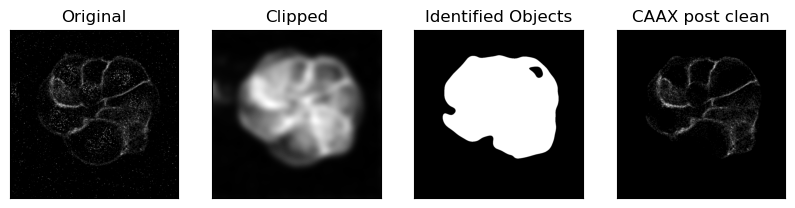

In [ ]:
correlation = load_image_and_extract_correlation(spot_files[SPOT_CHECK_INDEX], to_plot=True, no_channels=NUM_CHANNELS)


In [ ]:
correlation


,DAPI,YAP,CAAX,Vinculin,filename,flag,well,day,condition,image_type
DAPI,1.000000,0.019386,0.005407,0.069972,yapvincd1softwell12p0zoom004.tif,None,1,1,soft,"soft, d1"
YAP,0.019386,1.000000,0.228988,0.632490,yapvincd1softwell12p0zoom004.tif,None,1,1,soft,"soft, d1"
CAAX,0.005407,0.228988,1.000000,0.277531,yapvincd1softwell12p0zoom004.tif,None,1,1,soft,"soft, d1"
Vinculin,0.069972,0.632490,0.277531,1.000000,yapvincd1softwell12p0zoom004.tif,None,1,1,soft,"soft, d1"


## Run the full batch

For each experiment listed in `EXPERIMENTS`, scan `ROOT_DIR/<experiment>/final_tifs/**/*.tif`, extract correlations in parallel, and write a CSV to `OUTPUT_DIR`.

Edit `EXPERIMENTS_TO_RUN` below to skip any you don't want.


In [ ]:
EXPERIMENTS_TO_RUN = ["Yap_Vinc"]

results: dict[str, pd.DataFrame] = {}
for experiment in EXPERIMENTS_TO_RUN:
    image_dir = ROOT_DIR / experiment / "final_tifs"
    files = sorted(image_dir.glob("**/*.tif"))
    if not files:
        print(f"  [skip] {experiment}: no TIFs found in {image_dir}")
        continue

    print(f"\n→ {experiment}: {len(files)} files")
    with tqdm_joblib(tqdm(desc=experiment, total=len(files))) as _:
        per_image = Parallel(n_jobs=NUM_WORKERS)(
            delayed(load_image_and_extract_correlation)(p) for p in files
        )

    df = pd.concat(per_image, ignore_index=False)
    out_path = OUTPUT_DIR / f"{experiment.lower().replace('_', '')}_colocalisation.csv"
    df.to_csv(out_path)
    results[experiment] = df
    print(f"  saved → {out_path}  ({len(df)} rows, {df['flag'].value_counts().to_dict()})")


Image Analysis: 100%|██████████| 140/140 [57:31<00:00, 24.66s/it] 
